# Model Comparison: ResNet Classifier vs YOLO Detectors
This notebook compares the best trained versions of three models in this repository:
- ResNet defect classification model (.keras/.h5)
- YOLO Enhanced detector (trained_models/enhanced_yolo_defect_detector)
- YOLO Label Studio detector (trained_models/labelstudio_*/weights)
We evaluate quantitative metrics (accuracy, precision, recall, F1, ROC-AUC, PR-AUC), latency, and visualize qualitative results side-by-side.

In [1]:
# 1) Setup Environment and Imports
import os, sys, json, glob, time, math, random, logging
from time import perf_counter
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve
)

# Prefer CPU for consistency unless GPU is desired
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # suppress TF info logs

try:
    import tensorflow as tf
except Exception as e:
    print("TensorFlow not available yet, will try later:", e)

# Matplotlib defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [2]:
# 2) Resolve Project Root and Enable Logging
repo_root = "/Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(name)s - %(message)s")
logger = logging.getLogger("notebook")
logger.info("Notebook started. Repo root added to sys.path.")

2025-09-21 13:45:35,604 - INFO - notebook - Notebook started. Repo root added to sys.path.


In [3]:
# 3) Locate Best Model Artifacts (ResNet, YOLO Enhanced, YOLO Label Studio)
def pick_first_existing(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None

# ResNet classifier
resnet_candidates = [
    "trained_models/enhanced_resnet_defect_classifier.keras",
    "trained_models/enhanced_resnet_defect_classifier.h5",
    "trained_models/final_defect_model.h5",
    "enhanced_resnet_defect_classifier.keras",
    "enhanced_resnet_defect_classifier.h5",
]
resnet_path = pick_first_existing([os.path.join(repo_root, p) for p in resnet_candidates])

# YOLO Enhanced
yolo_enh_candidates = [
    "trained_models/enhanced_yolo_defect_detector/weights/best.pt",
    "trained_models/enhanced_yolo_defect_detector/weights/last.pt",
]
yolo_enh_path = pick_first_existing([os.path.join(repo_root, p) for p in yolo_enh_candidates])

# YOLO Label Studio (match first best.pt found)
yolo_ls_glob = glob.glob(os.path.join(repo_root, "trained_models", "labelstudio_*", "weights", "best.pt"))
yolo_ls_path = yolo_ls_glob[0] if yolo_ls_glob else None

print("Resolved paths:")
print("ResNet:", resnet_path)
print("YOLO Enhanced:", yolo_enh_path)
print("YOLO Label Studio:", yolo_ls_path)

assert resnet_path is not None, "ResNet model not found in expected locations"
assert yolo_enh_path is not None, "YOLO Enhanced model not found in expected locations"
assert yolo_ls_path is not None, "YOLO Label Studio best.pt not found"

Resolved paths:
ResNet: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/enhanced_resnet_defect_classifier.keras
YOLO Enhanced: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/enhanced_yolo_defect_detector/weights/best.pt
YOLO Label Studio: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/labelstudio_chocopie_detector/weights/best.pt


In [4]:
# 4) Instantiate and Load Models via project classes
from abbvisionsystem.models.resnet_model import ResnetModel
from abbvisionsystem.models.yolo_model import YOLODefectModel

resnet = ResnetModel.create_with_path(resnet_path)
ok_resnet = resnet.load()
print("ResNet loaded:", ok_resnet, resnet.get_model_info())

yolo_enh = YOLODefectModel.create_with_path(yolo_enh_path)
ok_yolo_enh = yolo_enh.load() if hasattr(yolo_enh, 'load') else True
print("YOLO Enhanced loaded:", ok_yolo_enh, yolo_enh.get_model_info())

yolo_ls = YOLODefectModel.create_with_path(yolo_ls_path)
ok_yolo_ls = yolo_ls.load() if hasattr(yolo_ls, 'load') else True
print("YOLO Label Studio loaded:", ok_yolo_ls, yolo_ls.get_model_info())

2025-09-21 13:45:35,621 - INFO - abbvisionsystem.models.defect_detection_model - Found keras model path in info file: trained_models/enhanced_resnet_defect_classifier.keras
2025-09-21 13:45:35,621 - INFO - abbvisionsystem.models.defect_detection_model - Attempting to load model from keras path: trained_models/enhanced_resnet_defect_classifier.keras
2025-09-21 13:45:35,621 - INFO - abbvisionsystem.models.defect_detection_model - Attempting to load model from keras path: trained_models/enhanced_resnet_defect_classifier.keras
2025-09-21 13:45:36,425 - INFO - abbvisionsystem.models.defect_detection_model - Successfully loaded model from: trained_models/enhanced_resnet_defect_classifier.keras
2025-09-21 13:45:36,425 - INFO - abbvisionsystem.models.defect_detection_model - Successfully loaded model from: trained_models/enhanced_resnet_defect_classifier.keras


ResNet loaded: True {'model_path': '/Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/enhanced_resnet_defect_classifier.keras', 'loaded': True, 'model_type': 'DefectDetectionModel', 'file_size_mb': 207.22861003875732, 'file_exists': True, 'modified': '2025-09-03 22:59'}


2025-09-21 13:45:37,781 - INFO - abbvisionsystem.models.yolo_model - Loading YOLO model from: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/enhanced_yolo_defect_detector/weights/best.pt
2025-09-21 13:45:37,827 - INFO - abbvisionsystem.models.yolo_model - YOLO model loaded successfully: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/enhanced_yolo_defect_detector/weights/best.pt
2025-09-21 13:45:37,828 - INFO - abbvisionsystem.models.yolo_model - Loading YOLO model from: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/labelstudio_chocopie_detector/weights/best.pt
2025-09-21 13:45:37,827 - INFO - abbvisionsystem.models.yolo_model - YOLO model loaded successfully: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/enhanced

YOLO Enhanced loaded: True {'model_path': '/Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/enhanced_yolo_defect_detector/weights/best.pt', 'loaded': True, 'categories': {0: {'name': 'Normal', 'id': 0}, 1: {'name': 'Defect', 'id': 1}}, 'file_size_mb': 18.294946670532227, 'file_exists': True}
YOLO Label Studio loaded: True {'model_path': '/Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/trained_models/labelstudio_chocopie_detector/weights/best.pt', 'loaded': True, 'categories': {0: {'name': 'Normal', 'id': 0}, 1: {'name': 'Defect', 'id': 1}}, 'file_size_mb': 18.282495498657227, 'file_exists': True}


In [5]:
# 5) Configure Evaluation Dataset and Ground Truth
eval_root = os.path.join(repo_root, "data", "eval")
normal_dir = os.path.join(eval_root, "normal")
defect_dir = os.path.join(eval_root, "defect")

def list_images(d):
    if not os.path.exists(d):
        return []
    exts = (".jpg", ".jpeg", ".png", ".bmp")
    out = []
    for root, _, files in os.walk(d):
        for fn in files:
            if fn.lower().endswith(exts):
                out.append(os.path.join(root, fn))
    return sorted(out)

normal_imgs = list_images(normal_dir)
defect_imgs = list_images(defect_dir)

# Fallback: if no eval set, sample a few images from data/choco-pie/* as demo
if not normal_imgs and not defect_imgs:
    demo_root = os.path.join(repo_root, "data", "choco-pie")
    both_dir = os.path.join(demo_root, "both")
    defect_only_dir = os.path.join(demo_root, "defect")
    # heuristic: treat 'defect' folder as defects; use some from 'both' as normal
    normal_imgs = list_images(both_dir)[:20]
    defect_imgs = list_images(defect_only_dir)[:20]

rows = []
for p in normal_imgs:
    rows.append({"path": p, "label": 0})
for p in defect_imgs:
    rows.append({"path": p, "label": 1})

df = pd.DataFrame(rows)
if len(df) == 0:
    raise RuntimeError("No evaluation images found. Populate data/eval/normal and data/eval/defect or adjust fallback paths.")

df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)
print("Eval dataset size:", len(df))
df.head()

Eval dataset size: 31


,path,label
0,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1
1,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1
2,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1
3,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1
4,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,0


In [ ]:
# 6) Define Unified Prediction API for All Models
def read_image_bgr(path):
    img = cv2.imread(path)
    if img is None:
        raise RuntimeError(f"Failed to read image: {path}")
    return img

def resnet_predict_score(model: ResnetModel, img_bgr) -> float:
    img = cv2.resize(img_bgr, (224, 224))
    img = img.astype("float32") / 255.0
    pred = model.model.predict(np.expand_dims(img, 0), verbose=0)
    score = float(pred[0][0])
    return score

def yolo_defect_score(detections: dict) -> float:
    # detections from our YOLO wrapper: classes array with 0=Normal, 1=Defect, and scores
    if detections is None or detections.get("num_detections", 0) == 0:
        return 0.0
    classes = detections.get("classes", np.array([]))
    scores = detections.get("scores", np.array([]))
    if classes.size == 0 or scores.size == 0:
        return 0.0
    defect_scores = [float(scores[i]) for i in range(len(scores)) if int(classes[i]) == 1]
    return max(defect_scores) if defect_scores else 0.0

def predict_image(model, model_kind: str, image_path: str, conf=0.25, iou=0.45):
    img = read_image_bgr(image_path)
    if model_kind == "resnet":
        score = resnet_predict_score(model, img)
        return {
            "defect_score": score,
            "has_defect": bool(score >= 0.5),
            "raw": score,
        }
    elif model_kind in ("yolo_enh", "yolo_ls"):
        det = model.predict(img, conf_threshold=conf, iou_threshold=iou)
        score = yolo_defect_score(det)
        return {
            "defect_score": score,
            "has_defect": bool(score >= conf),
            "raw": det,
        }
    else:
        raise ValueError(f"Unknown model_kind: {model_kind}")

In [7]:
# 7) Batch Inference and Timing
results = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    path = row['path']; y_true = int(row['label'])
    # ResNet
    t0 = perf_counter(); r_res = predict_image(resnet, 'resnet', path); t1 = perf_counter()
    # YOLO Enhanced
    t2 = perf_counter(); r_enh = predict_image(yolo_enh, 'yolo_enh', path); t3 = perf_counter()
    # YOLO Label Studio
    t4 = perf_counter(); r_ls = predict_image(yolo_ls, 'yolo_ls', path); t5 = perf_counter()
    results.append({
        'path': path, 'y_true': y_true,
        'resnet_score': r_res['defect_score'], 'resnet_pred': int(r_res['has_defect']), 'resnet_latency_ms': (t1-t0)*1000.0,
        'yolo_enh_score': r_enh['defect_score'], 'yolo_enh_pred': int(r_enh['has_defect']), 'yolo_enh_latency_ms': (t3-t2)*1000.0,
        'yolo_ls_score': r_ls['defect_score'], 'yolo_ls_pred': int(r_ls['has_defect']), 'yolo_ls_latency_ms': (t5-t4)*1000.0,
    })
results_df = pd.DataFrame(results)
results_df.head()

  0%|          | 0/31 [00:00<?, ?it/s]2025-09-21 13:45:39,879 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:39,879 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:40,030 - INFO - abbvisionsystem.models.yolo_model - No objects detected
  3%|▎         | 1/31 [00:02<01:02,  2.10s/it]2025-09-21 13:45:40,207 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:40,207 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:40,297 - INFO - abbvisionsystem.models.yolo_model - No objects detected
  6%|▋         | 2/31 [00:02<00:29,  1.02s/it]2025-09-21 13:45:40,472 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:40,472 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:40,562 - INFO - abbvisionsystem.models.yolo_model - No objects detect

,path,y_true,resnet_score,resnet_pred,resnet_latency_ms,yolo_enh_score,yolo_enh_pred,yolo_enh_latency_ms,yolo_ls_score,yolo_ls_pred,yolo_ls_latency_ms
0,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1,0.010419,0,823.045708,0.886858,1,1120.930834,0.000000,0,151.216041
1,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1,0.016680,0,84.559708,0.897319,1,90.878833,0.000000,0,89.302500
2,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1,0.009850,0,83.580667,0.896419,1,91.738125,0.000000,0,89.812542
3,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,1,0.010476,0,86.001958,0.880629,1,90.506500,0.000000,0,88.823666
4,/Users/ducle/Library/CloudStorage/OneDrive-RMI...,0,0.031246,0,102.840375,0.940320,1,111.839417,0.905931,1,114.868041


In [8]:
# 8) Compute Metrics (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC)
def summarize_binary(y_true, scores, preds, name):
    metrics = {}
    metrics['model'] = name
    metrics['accuracy'] = accuracy_score(y_true, preds)
    metrics['precision'] = precision_score(y_true, preds, zero_division=0)
    metrics['recall'] = recall_score(y_true, preds, zero_division=0)
    metrics['f1'] = f1_score(y_true, preds, zero_division=0)
    try:
        metrics['roc_auc'] = roc_auc_score(y_true, scores)
    except Exception:
        metrics['roc_auc'] = float('nan')
    try:
        metrics['pr_auc'] = average_precision_score(y_true, scores)
    except Exception:
        metrics['pr_auc'] = float('nan')
    cm = confusion_matrix(y_true, preds)
    metrics['confusion_matrix'] = cm
    return metrics

y_true = results_df['y_true'].values
m_res = summarize_binary(y_true, results_df['resnet_score'].values, results_df['resnet_pred'].values, 'ResNet')
m_enh = summarize_binary(y_true, results_df['yolo_enh_score'].values, results_df['yolo_enh_pred'].values, 'YOLO Enhanced')
m_ls  = summarize_binary(y_true, results_df['yolo_ls_score'].values,  results_df['yolo_ls_pred'].values,  'YOLO LabelStudio')
summary_df = pd.DataFrame([
    {k: (v if k != 'confusion_matrix' else None) for k, v in m_res.items()},
    {k: (v if k != 'confusion_matrix' else None) for k, v in m_enh.items()},
    {k: (v if k != 'confusion_matrix' else None) for k, v in m_ls.items()},
])
summary_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,confusion_matrix
0,ResNet,0.354839,0.000000,0.0,0.000000,0.0,0.445948,None
1,YOLO Enhanced,0.645161,0.645161,1.0,0.784314,0.0,0.445948,None
2,YOLO LabelStudio,0.000000,0.000000,0.0,0.000000,0.0,0.645161,None


We compute F1 as:
$$F1 = 2 \cdot \frac{P \cdot R}{P + R}$$

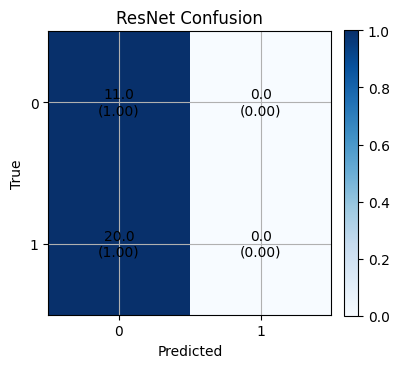

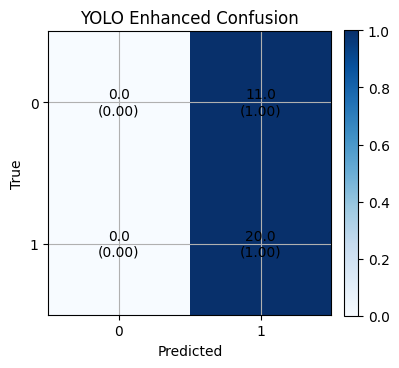

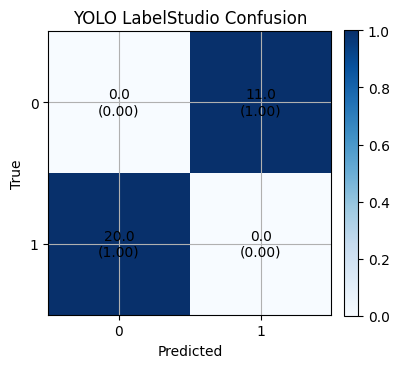

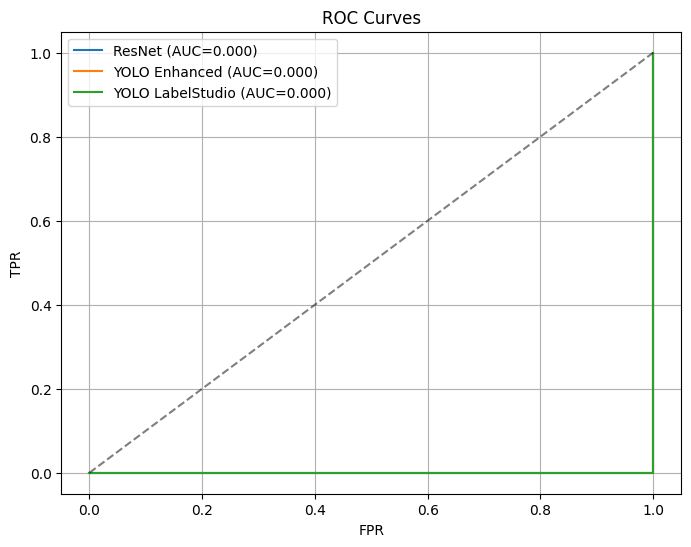

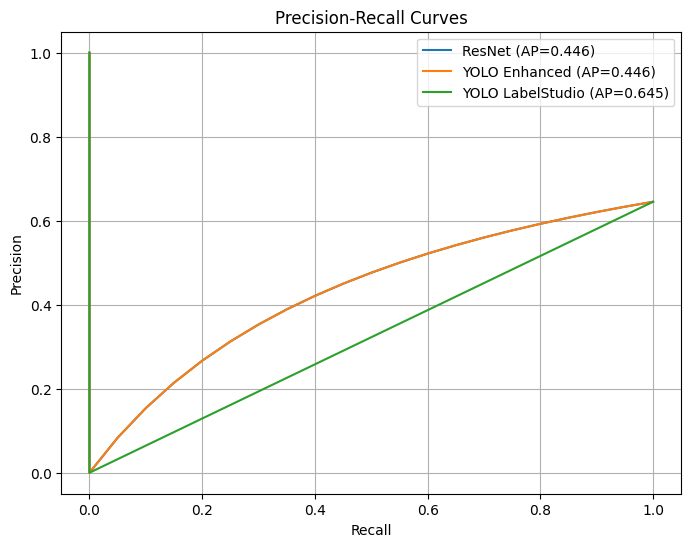

In [9]:
# 9) Plot Confusion Matrices and Curves
def plot_confusion(cm, title):
    import itertools
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    cm = cm.astype(np.float64)
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, f"{cm[i,j]}\n({cmn[i,j]:.2f})", ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

plot_confusion(m_res['confusion_matrix'], 'ResNet Confusion')
plot_confusion(m_enh['confusion_matrix'], 'YOLO Enhanced Confusion')
plot_confusion(m_ls['confusion_matrix'],  'YOLO LabelStudio Confusion')

# ROC and PR Curves
def plot_curves(y_true, scores_dict):
    # ROC
    plt.figure(figsize=(8,6))
    for name, scores in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc = roc_auc_score(y_true, scores)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1],'k--', alpha=0.5)
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves')
    plt.legend(); plt.show()
    # PR
    plt.figure(figsize=(8,6))
    for name, scores in scores_dict.items():
        prec, rec, _ = precision_recall_curve(y_true, scores)
        ap = average_precision_score(y_true, scores)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curves')
    plt.legend(); plt.show()

plot_curves(y_true, {
    'ResNet': results_df['resnet_score'].values,
    'YOLO Enhanced': results_df['yolo_enh_score'].values,
    'YOLO LabelStudio': results_df['yolo_ls_score'].values,
})

2025-09-21 13:45:49,134 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:49,219 - INFO - abbvisionsystem.models.yolo_model - No objects detected
2025-09-21 13:45:49,219 - INFO - abbvisionsystem.models.yolo_model - No objects detected


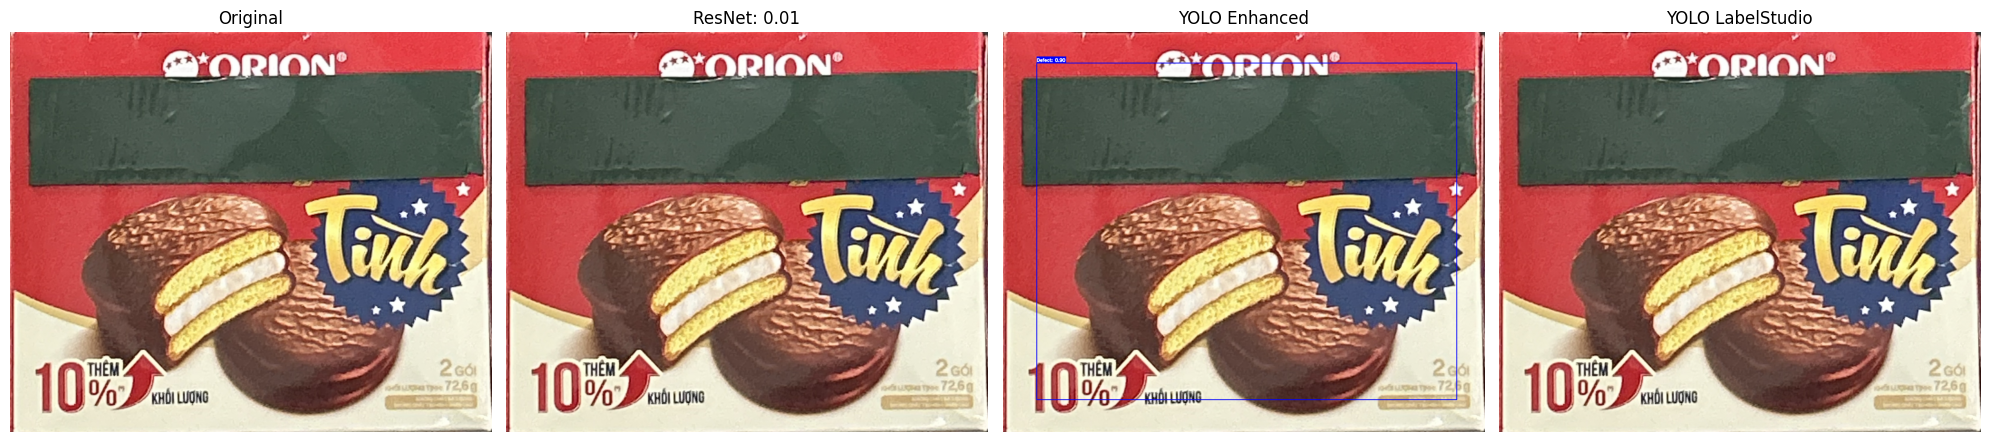

2025-09-21 13:45:49,773 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:49,854 - INFO - abbvisionsystem.models.yolo_model - No objects detected
2025-09-21 13:45:49,854 - INFO - abbvisionsystem.models.yolo_model - No objects detected


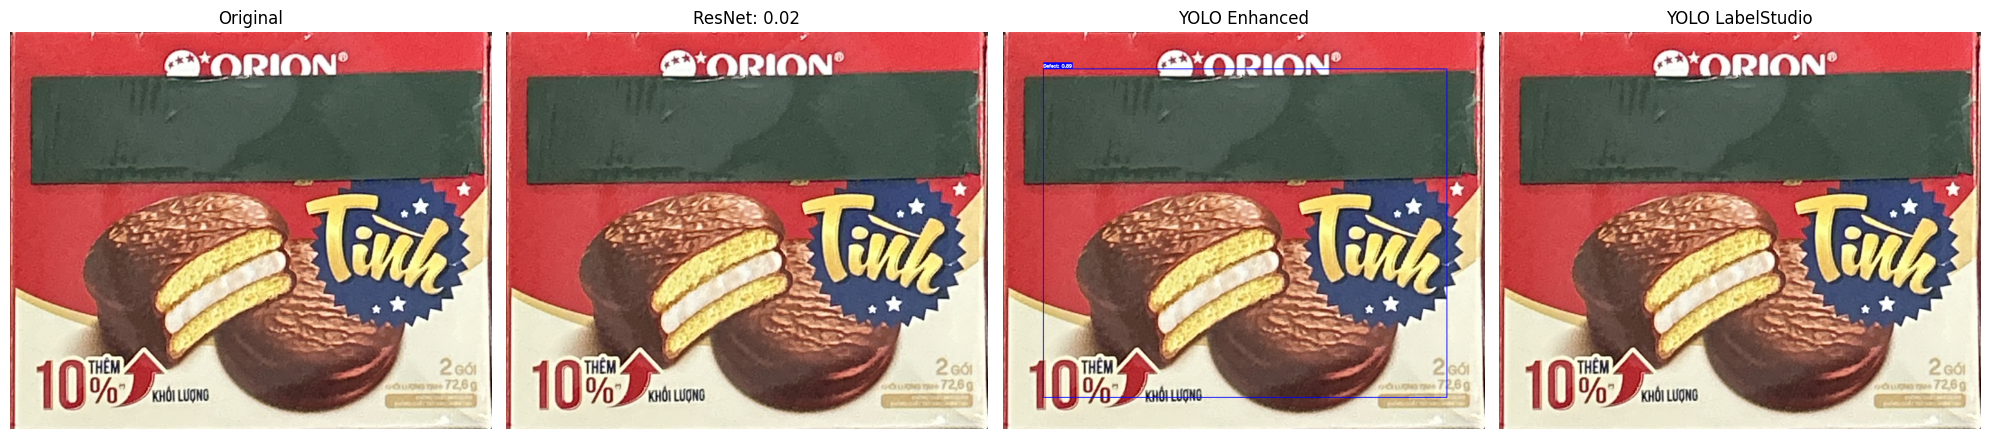

2025-09-21 13:45:50,362 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:50,445 - INFO - abbvisionsystem.models.yolo_model - No objects detected
2025-09-21 13:45:50,445 - INFO - abbvisionsystem.models.yolo_model - No objects detected


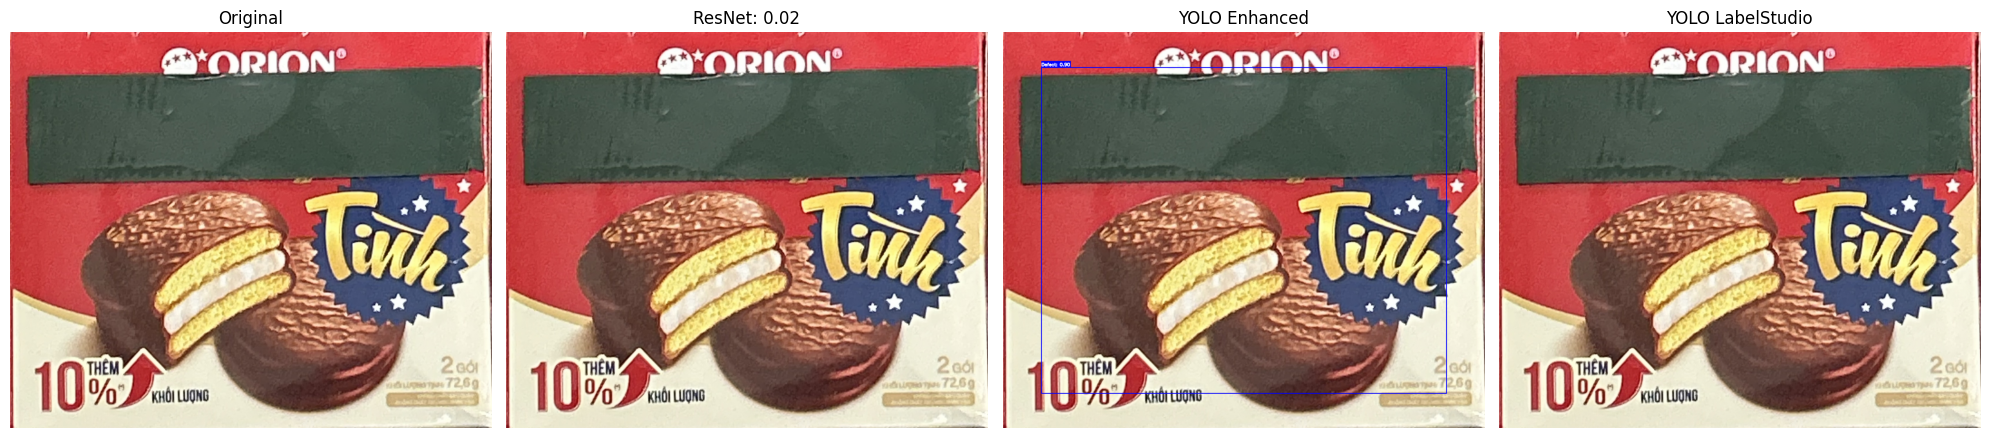

2025-09-21 13:45:50,991 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 2 objects
2025-09-21 13:45:51,070 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 2 objects
2025-09-21 13:45:51,070 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 2 objects


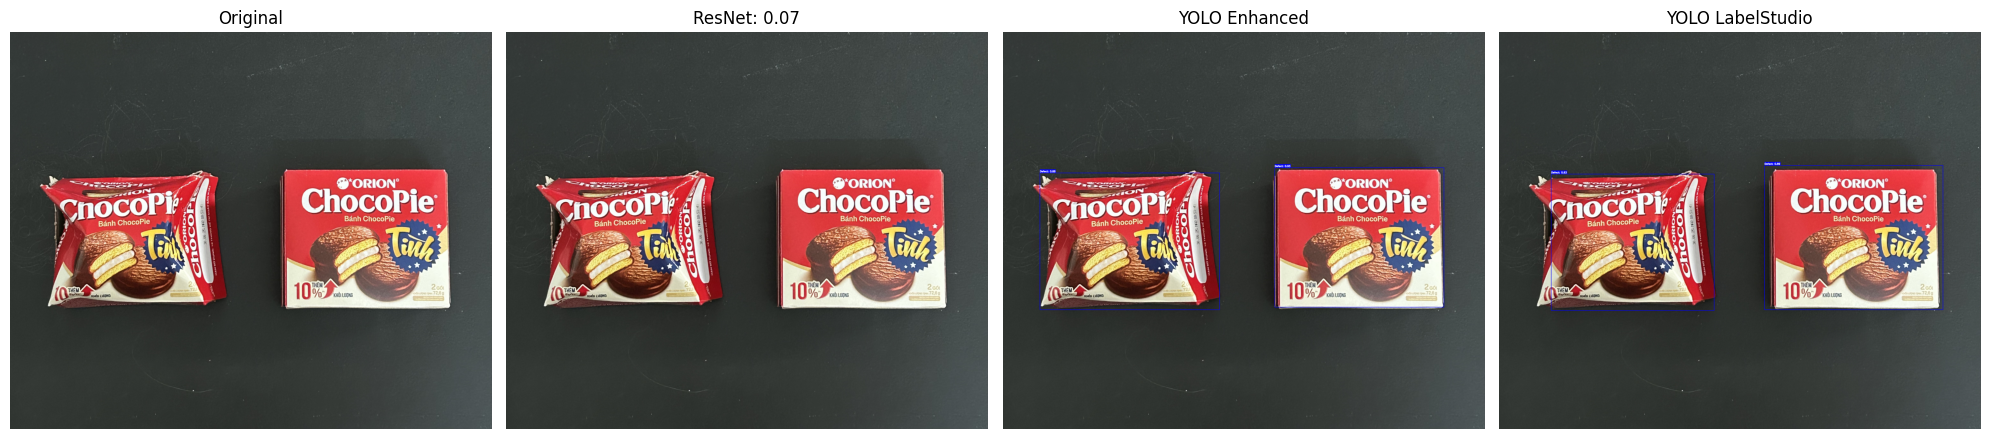

2025-09-21 13:45:52,096 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 1 objects
2025-09-21 13:45:52,179 - INFO - abbvisionsystem.models.yolo_model - No objects detected
2025-09-21 13:45:52,179 - INFO - abbvisionsystem.models.yolo_model - No objects detected


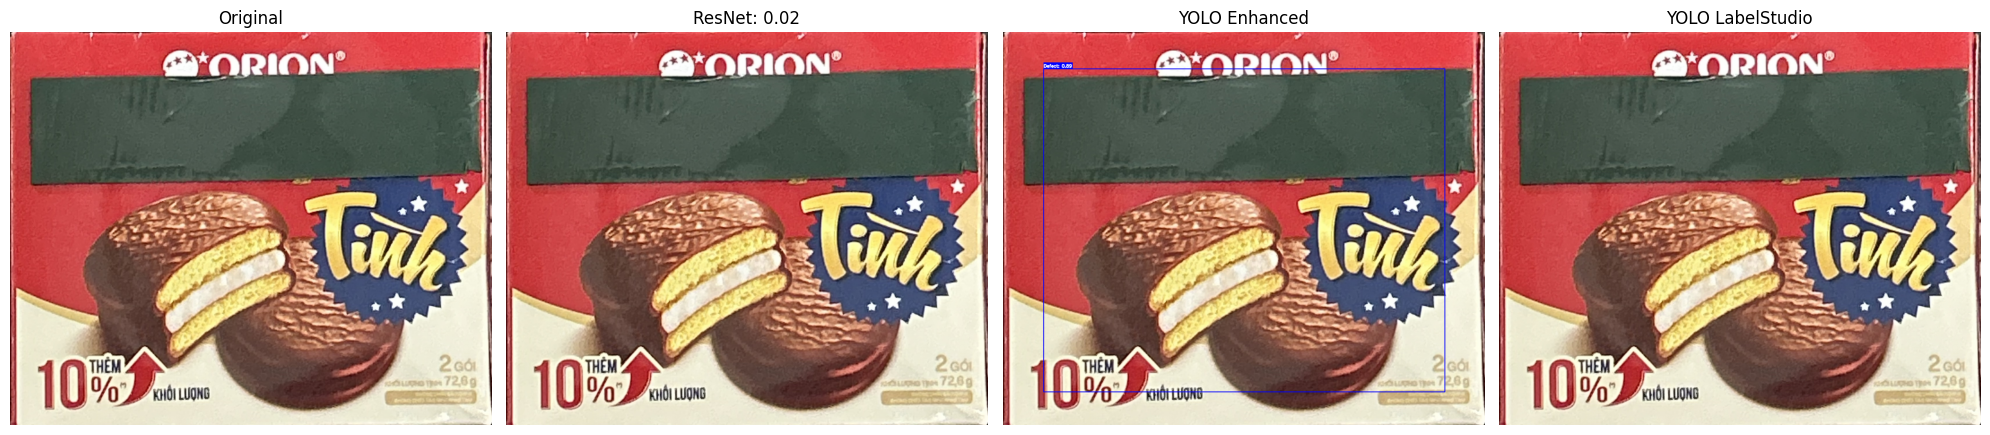

2025-09-21 13:45:52,755 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 2 objects
2025-09-21 13:45:52,891 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 3 objects
2025-09-21 13:45:52,891 - INFO - abbvisionsystem.models.yolo_model - Successfully detected 3 objects


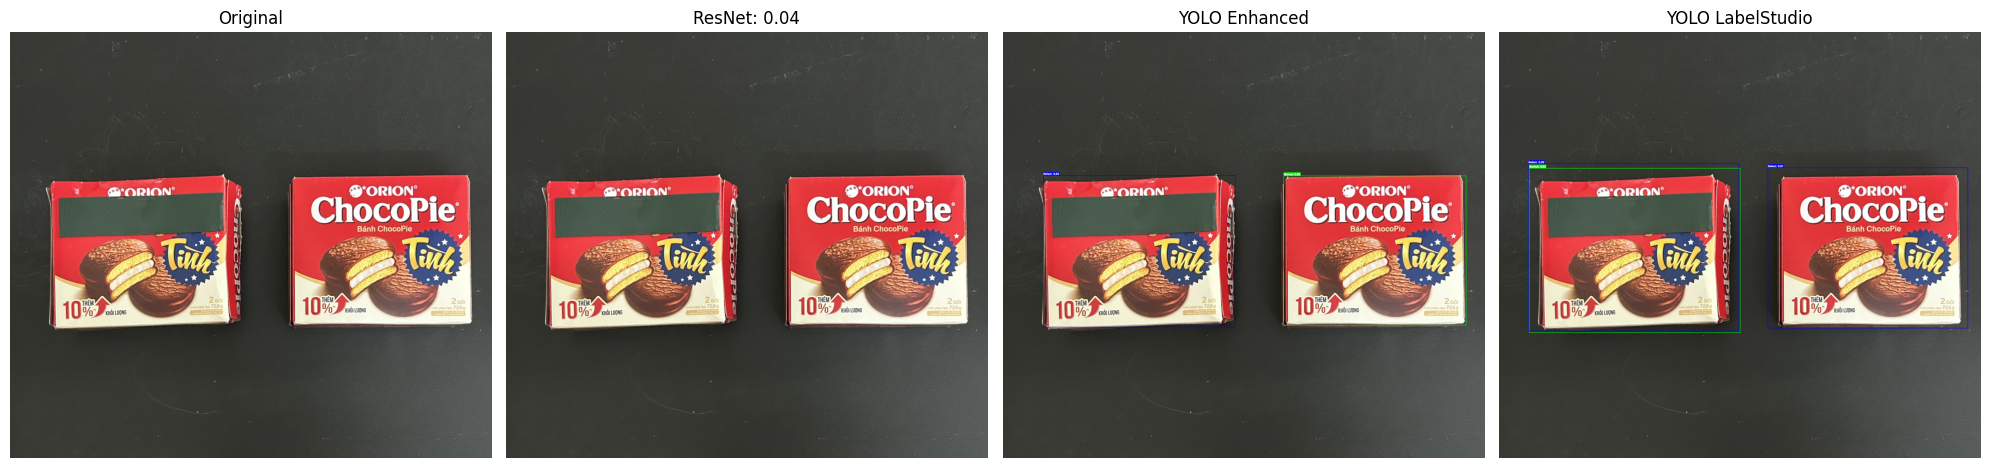

In [10]:
# 10) Qualitative Results: Visualize Predictions Side-by-Side
def visualize_model_outputs(image_path, resnet, yolo_enh, yolo_ls):
    img = cv2.imread(image_path)
    if img is None:
        raise RuntimeError(f"Could not read {image_path}")
    # ResNet pseudo-detection
    r_res = predict_image(resnet, 'resnet', image_path)
    det_res = {
        'boxes': np.array([[0.1,0.1,0.9,0.9]]),
        'scores': np.array([r_res['defect_score']]),
        'classes': np.array([1 if r_res['defect_score']>=0.5 else 0]),
        'num_detections': 1,
    }
    vis_resnet = resnet.visualize_detections(img, det_res, threshold=0.5)
    # YOLO Enhanced
    det_enh = yolo_enh.predict(img, conf_threshold=0.25, iou_threshold=0.45)
    vis_enh = yolo_enh.visualize_detections(img, det_enh, threshold=0.25)
    # YOLO Label Studio
    det_ls = yolo_ls.predict(img, conf_threshold=0.25, iou_threshold=0.45)
    vis_ls = yolo_ls.visualize_detections(img, det_ls, threshold=0.25)
    # Plot
    fig, axes = plt.subplots(1,4, figsize=(20,5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(vis_resnet, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"ResNet: {r_res['defect_score']:.2f}"); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(vis_enh, cv2.COLOR_BGR2RGB)); axes[2].set_title("YOLO Enhanced"); axes[2].axis('off')
    axes[3].imshow(cv2.cvtColor(vis_ls, cv2.COLOR_BGR2RGB)); axes[3].set_title("YOLO LabelStudio"); axes[3].axis('off')
    plt.tight_layout(); plt.show()

sample_vis = df.sample(n=min(6, len(df)), random_state=7)['path'].tolist()
for p in sample_vis:
    visualize_model_outputs(p, resnet, yolo_enh, yolo_ls)

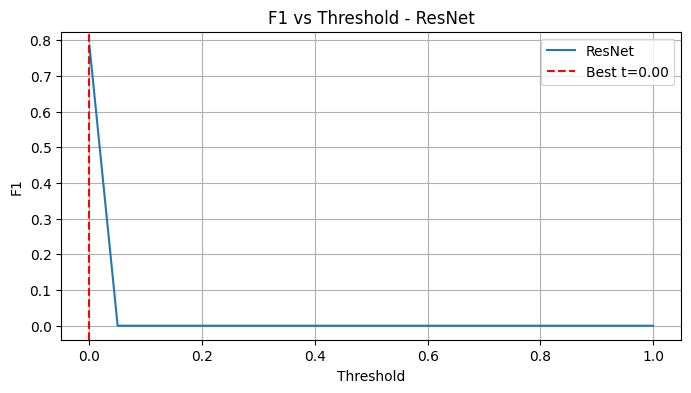

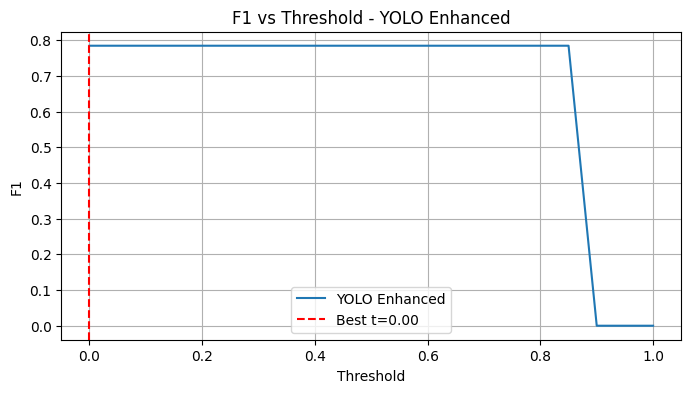

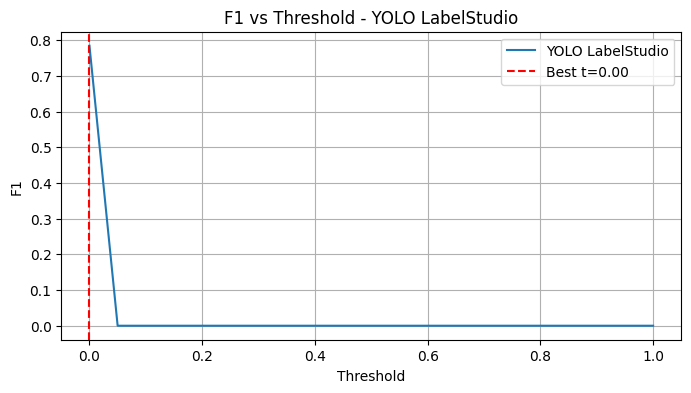

Best thresholds:
ResNet: {'threshold': np.float64(0.0), 'precision': np.float64(0.6451612903225806), 'recall': np.float64(1.0), 'f1': np.float64(0.7843137254901961)}
YOLO Enhanced: {'threshold': np.float64(0.0), 'precision': np.float64(0.6451612903225806), 'recall': np.float64(1.0), 'f1': np.float64(0.7843137254901961)}
YOLO LabelStudio: {'threshold': np.float64(0.0), 'precision': np.float64(0.6451612903225806), 'recall': np.float64(1.0), 'f1': np.float64(0.7843137254901961)}


In [11]:
# 11) Threshold Sensitivity Sweep
def threshold_sweep(y_true, scores, name, ts=np.linspace(0,1,21)):
    rows = []
    for t in ts:
        preds = (scores >= t).astype(int)
        rows.append({
            'threshold': t,
            'precision': precision_score(y_true, preds, zero_division=0),
            'recall': recall_score(y_true, preds, zero_division=0),
            'f1': f1_score(y_true, preds, zero_division=0)
        })
    df = pd.DataFrame(rows)
    best = df.iloc[df['f1'].idxmax()]
    plt.figure(figsize=(8,4))
    plt.plot(df['threshold'], df['f1'], label=f'{name}')
    plt.axvline(best['threshold'], color='r', linestyle='--', label=f"Best t={best['threshold']:.2f}")
    plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title(f'F1 vs Threshold - {name}')
    plt.legend(); plt.show()
    return df, best

s_res_df, s_res_best = threshold_sweep(y_true, results_df['resnet_score'].values, 'ResNet')
s_enh_df, s_enh_best = threshold_sweep(y_true, results_df['yolo_enh_score'].values, 'YOLO Enhanced')
s_ls_df,  s_ls_best  = threshold_sweep(y_true, results_df['yolo_ls_score'].values,  'YOLO LabelStudio')

print('Best thresholds:')
print('ResNet:', dict(s_res_best))
print('YOLO Enhanced:', dict(s_enh_best))
print('YOLO LabelStudio:', dict(s_ls_best))

In [12]:
# 12) Save Comparison Report (CSV/JSON)
out_dir = os.path.join(repo_root, "comparison_reports")
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "per_image_results.csv")
results_df.to_csv(csv_path, index=False)
print("Wrote:", csv_path)

summary = {
    'metrics': {
        'ResNet': {k: v for k, v in m_res.items() if k != 'confusion_matrix'},
        'YOLO_Enhanced': {k: v for k, v in m_enh.items() if k != 'confusion_matrix'},
        'YOLO_LabelStudio': {k: v for k, v in m_ls.items() if k != 'confusion_matrix'},
    },
    'best_thresholds': {
        'ResNet': dict(s_res_best),
        'YOLO_Enhanced': dict(s_enh_best),
        'YOLO_LabelStudio': dict(s_ls_best),
    },
    'model_paths': {
        'ResNet': resnet_path,
        'YOLO_Enhanced': yolo_enh_path,
        'YOLO_LabelStudio': yolo_ls_path,
    }
}
json_path = os.path.join(out_dir, "aggregate_summary.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print("Wrote:", json_path)

Wrote: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/comparison_reports/per_image_results.csv
Wrote: /Users/ducle/Library/CloudStorage/OneDrive-RMITUniversity/Courses/OENG1183 - Capstone A/abb-capstone/comparison_reports/aggregate_summary.json
